In [1]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
initialise_or_create_database_at("./2026-03-10_SNSPD4.db")
from functions import quick_check
from functions import calibrate
import snspd4

# Set up experiment
exp_name = 'SNSPD4_23_03_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260411-33240-qcodes.log
Experiment loaded. Last ID no: 459


# Parameters

In [2]:
params = snspd4.snspd4()

# Analysis

In [8]:
ID =  156
data = load_by_id(ID).get_parameter_data()
att_name = load_by_id(ID).metadata['attenuator_name']
# timestamp = load_by_id(ID).timestamp()
print(data['attenuation']['attenuation'])
print(att_name)
# print(timestamp)

[69.85005275]
VOA50PM


ID 156 taken without adjusting VOA50PM. Demonstrates that the attenuation did not change appreciably over the course of last week. 

In [9]:
ID =  161
data = load_by_id(ID).get_parameter_data()
att_name = load_by_id(ID).metadata['attenuator_name']
print(data['attenuation']['attenuation'])
print(att_name)

[60.38888867]
VOA50PM


Screw attenuator is set to approximately 60dB attenuation.

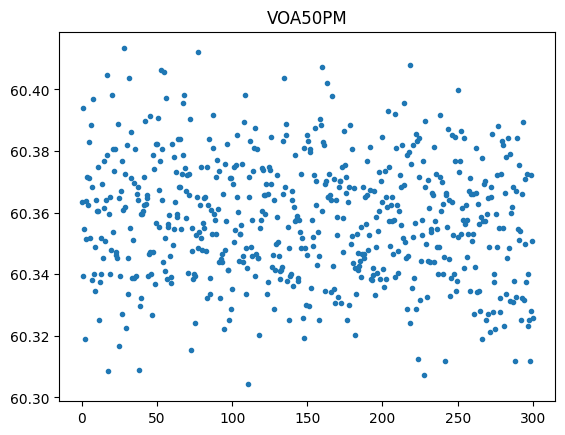

In [71]:
ID =  params.att_screw_calibration_id
data = load_by_id(ID).get_parameter_data()
att_name = load_by_id(ID).metadata['attenuator_name']
timestamp = load_by_id(ID).run_timestamp()
attenuation = data['attenuation']['attenuation']
time = data['times']['times']/2 # <- error in function at this moment where the times were calculated as samples

plt.plot(time, attenuation, '.')
plt.title(f'{att_name}')


In [17]:
ID =  106
data = load_by_id(ID).get_parameter_data()
# att_name = load_by_id(ID).metadata['attenuator_name']
# # timestamp = load_by_id(ID).timestamp()
# attenuation = data['attenuation']['attenuation']
# time = data['times']['times']/2 # <- error in function at this moment where the times were calculated as samples

# plt.plot(time, attenuation, '.')
# plt.title(f'{att_name}')

Previously using ID 242. ID 441 has results including average powers for photon number calculation. 

In [19]:
# meas = Measurement()
# meas.register_custom_parameter("ID_range", label="")
# meas.register_custom_parameter("v_attenuator", label="V")
# meas.register_custom_parameter("avg_attenuation", label="W")
# meas.register_custom_parameter("avg_power90", label="W")
# meas.register_custom_parameter("avg_power10", label="W")

# ID_range = np.arange(167, 240)
# v_range = np.arange(3.4, 7.05, 0.05)

# with meas.run() as datasaver: 
#     print(datasaver.run_id)
    
#     datasaver.dataset.add_metadata("attenuator_name", att_blue)
#     for i, ID in enumerate(ID_range): 
    
#         data = load_by_id(ID).get_parameter_data()
#         avg_attenuation = np.average(data['attenuation']['attenuation'])
#         avg_power90 = np.average(data['power90']['power90'])
#         avg_power10 = np.average(data['power10']['power10'])
        
#         datasaver.add_result(("ID_range", ID), 
#                              ("v_attenuator", v_range[i]),
#                              ("avg_attenuation", avg_attenuation),
#                             ("avg_power10", avg_power10),
#                             ("avg_power90", avg_power90),
#                              ("calibration_time", t),
#                             )
                                 

Starting experimental run with id: 441. 
441


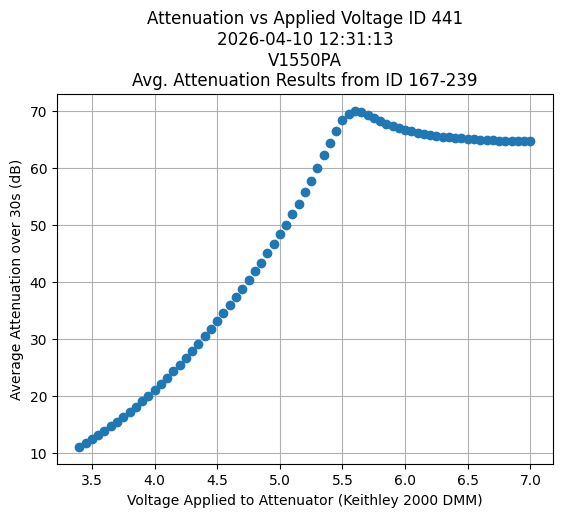

In [20]:
ID = params.att_blue_calibration_avg_id
data = load_by_id(ID).get_parameter_data()
timestamp = load_by_id(ID).run_timestamp()
att_name = load_by_id(ID).metadata['attenuator_name']
avg_attenuation = data['avg_attenuation']['avg_attenuation']
v_attenuator = data['v_attenuator']['v_attenuator']
ID_range = data['ID_range']['ID_range']
plot_title = f'Attenuation vs Applied Voltage'
conditions = f'Avg. Attenuation Results from ID {int(ID_range[0])}-{int(ID_range[-1])}'
title_string = f'{plot_title} ID {ID}\n{timestamp}\n{att_name}\n{conditions}'

plt.plot(v_attenuator, avg_attenuation, 'o')
plt.title(title_string)
plt.xlabel('Voltage Applied to Attenuator (Keithley 2000 DMM)')
plt.ylabel('Average Attenuation over 30s (dB)')
plt.grid()

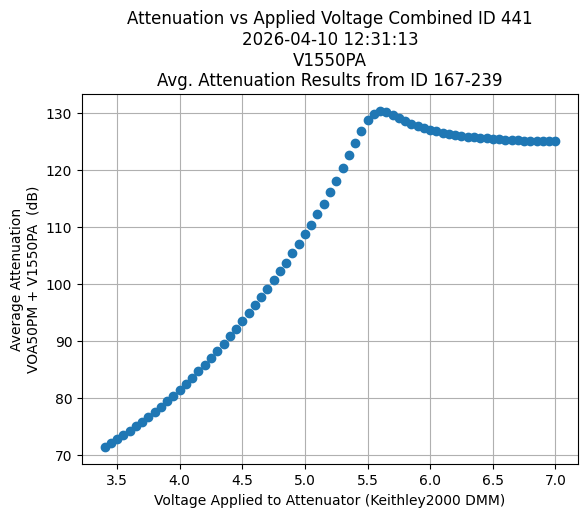

In [21]:
ID =  165
data = load_by_id(ID).get_parameter_data()
avg_attenuation_screw = np.average(data['attenuation']['attenuation'])

ID = params.att_blue_avg_id
data = load_by_id(ID).get_parameter_data()
timestamp = load_by_id(ID).run_timestamp()
att_name = load_by_id(ID).metadata['attenuator_name']
avg_attenuation = data['avg_attenuation']['avg_attenuation']
v_attenuator = data['v_attenuator']['v_attenuator']
ID_range = data['ID_range']['ID_range']
plot_title = f'Attenuation vs Applied Voltage Combined'
conditions = f'Avg. Attenuation Results from ID {int(ID_range[0])}-{int(ID_range[-1])}'
title_string = f'{plot_title} ID {ID}\n{timestamp}\n{att_name}\n{conditions}'

plt.plot(v_attenuator, avg_attenuation+avg_attenuation_screw, 'o')
plt.title(title_string)
plt.xlabel('Voltage Applied to Attenuator (Keithley2000 DMM)')
plt.ylabel(f'Average Attenuation\n{att_screw} + {att_blue}  (dB)')
plt.grid()

Including calibration time in average result for completeness

In [6]:
ID = 167
data = load_by_id(ID).get_parameter_data()
avg_attenuation = np.average(data['attenuation']['attenuation'])
avg_power90 = np.average(data['power90']['power90'])
avg_power10 = np.average(data['power10']['power10'])
calibration_time = data['times']['times'][-1]  # select the last time 


In [7]:
calibration_time

np.float64(30.0)

In [11]:
# meas = Measurement()
# meas.register_custom_parameter("ID_range", label="")
# meas.register_custom_parameter("v_attenuator", label="V")
# meas.register_custom_parameter("avg_attenuation", label="W")
# meas.register_custom_parameter("avg_power90", label="W")
# meas.register_custom_parameter("avg_power10", label="W")
# meas.register_custom_parameter("calibration_time", label="s")

# ID_range = np.arange(167, 240)
# v_range = np.arange(3.4, 7.05, 0.05)

# with meas.run() as datasaver: 
#     print(datasaver.run_id)
    
#     datasaver.dataset.add_metadata("attenuator_name", params.att_blue_name)
#     for i, ID in enumerate(ID_range): 
    
#         data = load_by_id(ID).get_parameter_data()
#         avg_attenuation = np.average(data['attenuation']['attenuation'])
#         avg_power90 = np.average(data['power90']['power90'])
#         avg_power10 = np.average(data['power10']['power10'])
#         calibration_time = data['times']['times'][-1]
        
#         datasaver.add_result(("ID_range", ID), 
#                              ("v_attenuator", v_range[i]),
#                              ("avg_attenuation", avg_attenuation),
#                             ("avg_power10", avg_power10),
#                             ("avg_power90", avg_power90),
#                              ("calibration_time", calibration_time),
#                             )
                                 

Starting experimental run with id: 459. 
459


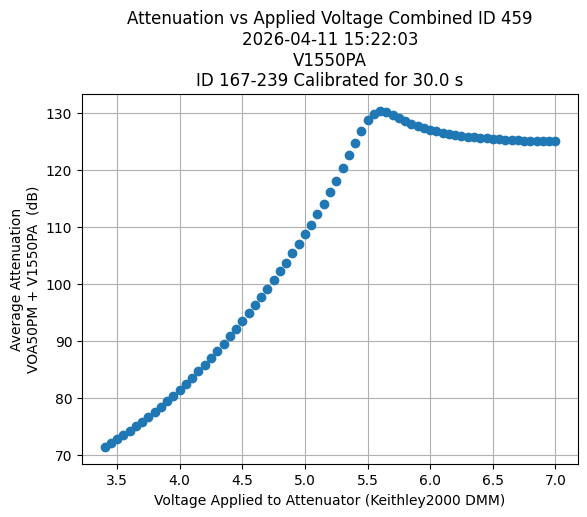

In [14]:
ID =  params.att_screw_calibration_id
data = load_by_id(ID).get_parameter_data()
avg_attenuation_screw = np.average(data['attenuation']['attenuation'])

ID = params.att_blue_calibration_avg_id
data = load_by_id(ID).get_parameter_data()
timestamp = load_by_id(ID).run_timestamp()
att_name = load_by_id(ID).metadata['attenuator_name']
avg_attenuation = data['avg_attenuation']['avg_attenuation']
v_attenuator = data['v_attenuator']['v_attenuator']
calibration_time = data['calibration_time']['calibration_time']
ID_range = data['ID_range']['ID_range']
plot_title = f'Attenuation vs Applied Voltage Combined'
conditions = f'ID {int(ID_range[0])}-{int(ID_range[-1])} Calibrated for {calibration_time[0]} s'
# \nCalibrated for {}s}'
title_string = f'{plot_title} ID {ID}\n{timestamp}\n{att_name}\n{conditions}'

plt.plot(v_attenuator, avg_attenuation+avg_attenuation_screw, 'o')
plt.title(title_string)
plt.xlabel('Voltage Applied to Attenuator (Keithley2000 DMM)')
plt.ylabel(f'Average Attenuation\n{params.att_screw_name} + {params.att_blue_name}  (dB)')
plt.grid()